In [1]:
import data_prep_obj as data_prep
import matplotlib.pyplot as plt

## filter the discharge with file size

In [2]:
spectro_analysis = False

discharge_min = 170000
discharge_max = 170010
discharge_search_list = range(discharge_min, discharge_max + 1)
suffix_list = ["ece_s", "co2_s", "ts", "co2_pl"]
prep_obj_1 = data_prep.DatasetPrep(discharge_search_list, suffix_list)
print(prep_obj_1.discharge_search_list)
print(prep_obj_1.suffix_list)

discharge_list = prep_obj_1.filter_discharges()
print(discharge_list)

range(170000, 170011)
['ece_s', 'co2_s', 'ts', 'co2_pl']


100%|████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 12798.15it/s]

{'ece_s': [170000, 170001, 170002, 170003, 170004, 170005, 170006, 170007, 170008, 170009, 170010], 'co2_s': [170000, 170001, 170002, 170003, 170004, 170005, 170006, 170007, 170008, 170009, 170010], 'ts': [170000, 170001, 170002, 170003, 170004, 170005, 170006, 170007, 170008, 170009, 170010], 'co2_pl': [170000, 170001, 170002, 170003, 170004, 170005, 170006, 170007, 170008, 170009, 170010]}


In [22]:
discharge = 174823
suffix = "mag"

discharge_obj = data_prep.DichargePerp(discharge, [suffix])
input_file = discharge_obj.get_data(discharge, suffix)
input_multi_level = discharge_obj.data_division(input_file, suffix)

file_dict = discharge_obj.get_full_data()

for key in file_dict.keys():
    print(key)
    print(file_dict[key].keys())
    for key2 in file_dict[key].keys():
        print(len(file_dict[key].keys()))

dict = list(input_file["core.z"]["zdata"])
print(dict)

mag
dict_keys(['dsl', 'mpi', 'psf', 'psi'])


KeyError: "Unable to open object (object 'core.z' doesn't exist)"

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

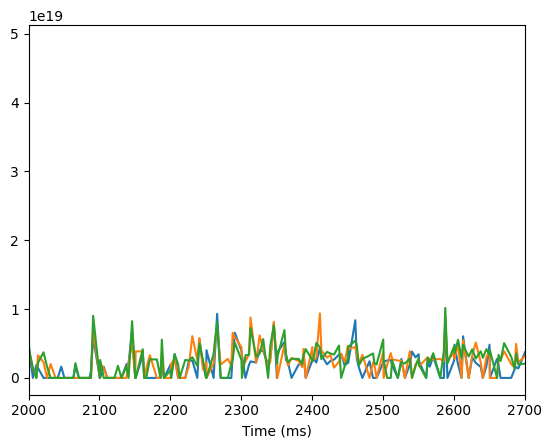

In [8]:
plt.clf()
plt.plot(dict["xdata"][:], dict["zdata"][:3, :].T)
plt.xlabel("Time (ms)")
plt.xlim(2000, 2700)
plt.ylim(0, 10**20)
plt.show()

In [4]:
# discharge_obj.plot_time_series(file_dict['co2_pl']['only']['r0'])

if spectro_analysis:
    freq, time, amp_f_t = discharge_obj.spectro_calc(
        file_dict["co2_pl"]["only"]["r0"]["xdata"][:],
        file_dict["co2_pl"]["only"]["r0"]["zdata"][:],
        plot=True,
    )

    freq_enhanced, time_enhanced, amp_f_t_enhanced = (
        discharge_obj.spec_filters(freq, time, amp_f_t)
    )

    discharge_obj.spectro_plot(freq_enhanced, time_enhanced, amp_f_t_enhanced)

In [5]:
time_std = file_dict["ts"]["core.temp"]["core.temp"]["xdata"][:]
time = file_dict["co2_s"]["only"]["r0"]["xdata"][:]
data = file_dict["co2_s"]["only"]["r0"]["zdata"][:]
matched_time, matched_data = discharge_obj.time_matching(
    time, data, time_std, mode="merge_asof"
)

plt.plot(matched_time, time_std)

KeyError: 'co2_s'

In [ ]:
time =file_dict['ts']['core.temp']['core.temp']['xdata'][:]
data =file_dict['ts']['core.temp']['core.temp']['zdata'][20,:]
time_std =file_dict['co2_pl']['only']['r0']['xdata'][:]

data_interp=discharge_obj.time_interp(time, data, time_std)

plt.plot(time_std,data_interp)
plt.plot(time,data)
plt.xlim(2100,2110)
